In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve
)

from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.mixture import GaussianMixture

from sklearn.cluster import KMeans

from sklearn.inspection import permutation_importance

import joblib
import os
import time

In [6]:
df = pd.read_csv("../data/numeric_pattern.csv")

os.makedirs("../outputs/models", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../report", exist_ok=True)

print(df.shape)
display(df.head())
display(df.tail())

df.info()

display(df.describe())

print(df.isnull().sum())

median_value = df["Target"].median()

df["Target"] = np.where(df["Target"] >= median_value, 1, 0)

print(df["Target"].value_counts())

(10050, 11)


,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
0,60.0,250533.570765,40.0,51.0,87.0,67.0,8.0,74.0,45.0,114.99086,38012.809185
1,54.0,223288.442691,34.0,87.0,67.0,52.0,1.0,65.0,65.0,109.00000,33979.169389
2,52.0,196879.233126,28.0,51.0,75.0,62.0,18.0,86.0,66.0,137.00000,29926.071273
3,57.0,235896.064078,35.0,50.0,88.0,60.0,14.0,81.0,81.0,99.00000,35906.153085
4,33.0,127252.628070,11.0,56.0,45.0,74.0,4.0,82.0,98.0,113.00000,19414.350215


,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
10045,28.0,119808.803883,3.000000,91.0,59.0,79.0,11.0,64.0,12.0,138.0,18085.763691
10046,36.0,158294.574688,16.000000,71.0,78.0,59.0,2.0,96.0,82.0,88.0,24038.313773
10047,52.0,179438.230387,28.000000,63.0,46.0,54.0,10.0,64.0,88.0,141.0,27314.251089
10048,49.0,191863.724037,24.000000,81.0,53.0,84.0,6.0,84.0,75.0,131.0,28883.431524
10049,52.0,200431.767775,17.668664,100.0,42.0,70.0,13.0,90.0,20.0,144.0,30326.875899


<class 'pandas.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Feature_1_Age            10050 non-null  float64
 1   Feature_2_Income         10050 non-null  float64
 2   Feature_3_Experience     10050 non-null  float64
 3   Feature_4_Education      10050 non-null  float64
 4   Feature_5_Skill          10050 non-null  float64
 5   Feature_6_Performance    10050 non-null  float64
 6   Feature_7_Projects       10050 non-null  float64
 7   Feature_8_Attendance     10050 non-null  float64
 8   Feature_9_TrainingHours  10050 non-null  float64
 9   Feature_10_IQ            10050 non-null  float64
 10  Target                   10050 non-null  float64
dtypes: float64(11)
memory usage: 863.8 KB


,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
count,10050.000000,1.005000e+04,10050.000000,10050.000000,10050.000000,10050.000000,10050.000000,10050.000000,10050.000000,10050.00000,10050.000000
mean,39.983452,1.740651e+05,17.668664,75.062335,69.872880,75.079188,10.610254,80.096456,107.291269,114.99086,25981.160479
std,11.740257,6.637673e+04,11.616778,14.591187,17.560061,14.671831,5.718830,11.709933,54.673714,20.26586,6405.977226
min,20.000000,7.211345e+04,0.000000,50.000000,40.000000,50.000000,1.000000,60.000000,10.000000,80.00000,10958.458281
25%,30.000000,1.350653e+05,7.000000,62.000000,55.000000,63.000000,6.000000,70.000000,60.000000,98.00000,20621.326320
50%,39.983452,1.721336e+05,17.668664,75.062335,69.872880,75.079188,11.000000,80.096456,108.000000,115.00000,25981.160479
75%,50.000000,2.054957e+05,27.000000,88.000000,85.000000,88.000000,16.000000,90.000000,154.000000,132.00000,31165.630167
max,60.000000,1.233181e+06,40.000000,100.000000,100.000000,100.000000,20.000000,100.000000,200.000000,150.00000,41836.145332


Feature_1_Age              0
Feature_2_Income           0
Feature_3_Experience       0
Feature_4_Education        0
Feature_5_Skill            0
Feature_6_Performance      0
Feature_7_Projects         0
Feature_8_Attendance       0
Feature_9_TrainingHours    0
Feature_10_IQ              0
Target                     0
dtype: int64
Target
1    5119
0    4931
Name: count, dtype: int64


In [7]:
X = df.drop("Target", axis=1)
y = df["Target"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)
print("\nTarget Distribution")
print(y.value_counts())

Training Shape : (8040, 10)
Testing Shape  : (2010, 10)

Target Distribution
Target
1    5119
0    4931
Name: count, dtype: int64


AdaBoost Accuracy : 0.9746
Training Time : 0.2999 seconds

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       986
           1       0.98      0.97      0.97      1024

    accuracy                           0.97      2010
   macro avg       0.97      0.97      0.97      2010
weighted avg       0.97      0.97      0.97      2010



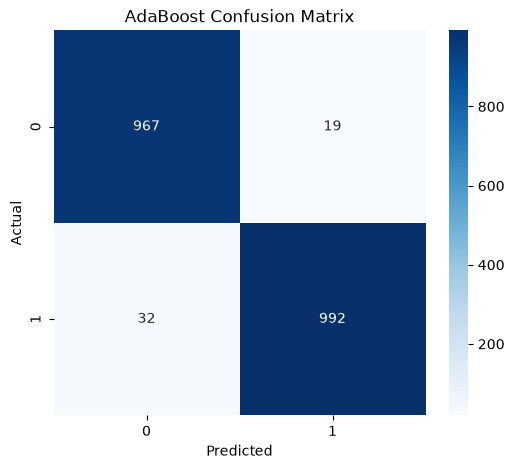

['../outputs/models/adaboost_model.pkl']

In [8]:
start = time.time()

adaboost = AdaBoostClassifier(
    random_state=42
)

adaboost.fit(X_train, y_train)

ada_pred = adaboost.predict(X_test)

ada_time = time.time() - start

ada_accuracy = accuracy_score(y_test, ada_pred)

print("AdaBoost Accuracy :", round(ada_accuracy, 4))
print("Training Time :", round(ada_time, 4), "seconds")

print("\nClassification Report\n")
print(classification_report(y_test, ada_pred))

cm = confusion_matrix(y_test, ada_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../outputs/figures/adaboost_confusion_matrix.png")

plt.show()

joblib.dump(
    adaboost,
    "../outputs/models/adaboost_model.pkl"
)

Extra Trees Accuracy : 0.9776
Training Time : 0.9629 seconds

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       986
           1       0.99      0.97      0.98      1024

    accuracy                           0.98      2010
   macro avg       0.98      0.98      0.98      2010
weighted avg       0.98      0.98      0.98      2010



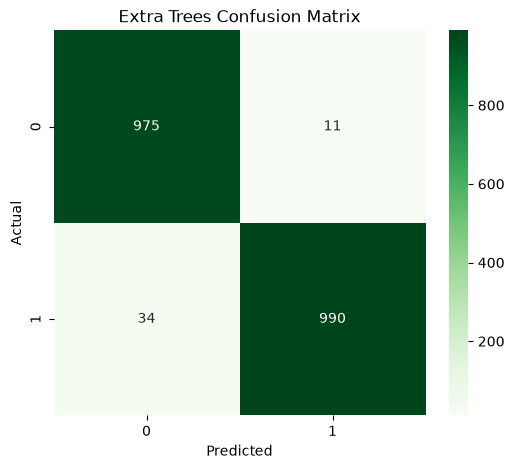

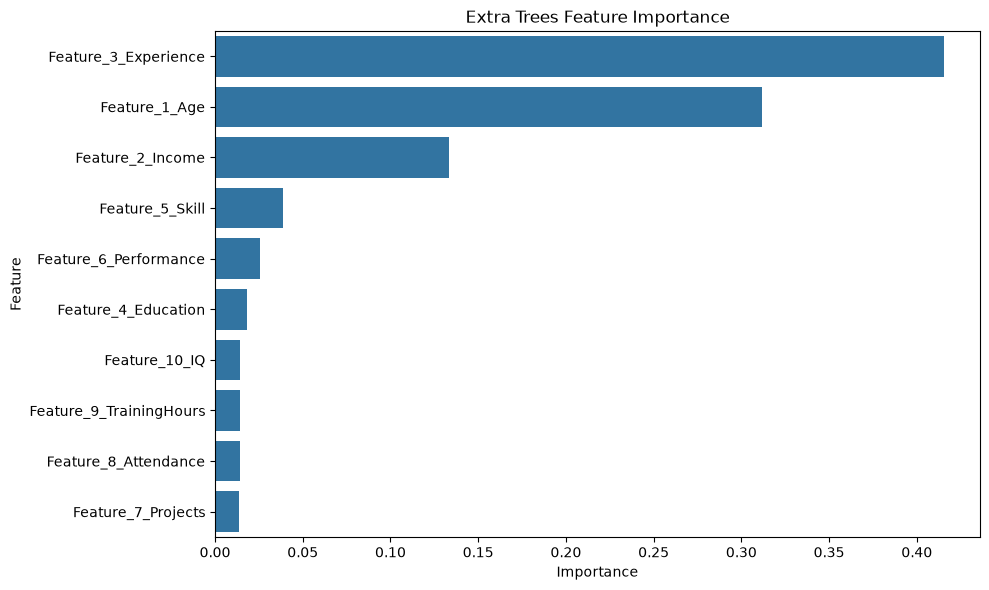

['../outputs/models/extratrees_model.pkl']

In [9]:
start = time.time()

extra = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)

extra.fit(X_train, y_train)

extra_pred = extra.predict(X_test)

extra_time = time.time() - start

extra_accuracy = accuracy_score(y_test, extra_pred)

print("Extra Trees Accuracy :", round(extra_accuracy,4))
print("Training Time :", round(extra_time,4),"seconds")

print("\nClassification Report\n")
print(classification_report(y_test, extra_pred))

cm = confusion_matrix(y_test, extra_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Extra Trees Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../outputs/figures/extratrees_confusion_matrix.png")

plt.show()

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": extra.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Extra Trees Feature Importance")

plt.tight_layout()

plt.savefig("../outputs/figures/feature_importance.png")

plt.show()

joblib.dump(
    extra,
    "../outputs/models/extratrees_model.pkl"
)

HistGradientBoosting Accuracy : 0.9821
Training Time : 2.4055 seconds

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       986
           1       0.99      0.97      0.98      1024

    accuracy                           0.98      2010
   macro avg       0.98      0.98      0.98      2010
weighted avg       0.98      0.98      0.98      2010



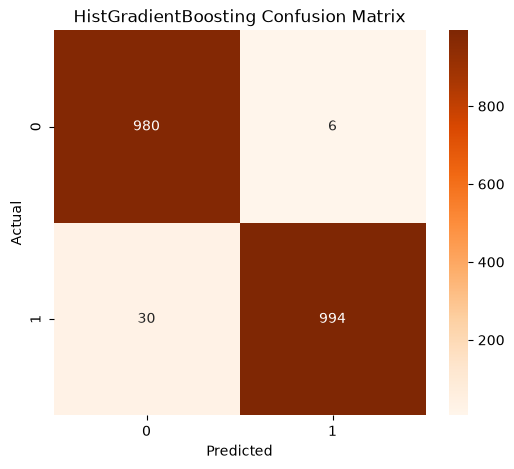

['../outputs/models/histgradientboosting_model.pkl']

In [10]:
start = time.time()

hgb = HistGradientBoostingClassifier(
    random_state=42,
    max_iter=200
)

hgb.fit(X_train, y_train)

hgb_pred = hgb.predict(X_test)

hgb_time = time.time() - start

hgb_accuracy = accuracy_score(y_test, hgb_pred)

print("HistGradientBoosting Accuracy :", round(hgb_accuracy,4))
print("Training Time :", round(hgb_time,4),"seconds")

print("\nClassification Report\n")
print(classification_report(y_test, hgb_pred))

cm = confusion_matrix(y_test, hgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("HistGradientBoosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../outputs/figures/hgb_confusion_matrix.png")

plt.show()

joblib.dump(
    hgb,
    "../outputs/models/histgradientboosting_model.pkl"
)

,Model,Mean CV Accuracy,Training Time (s),Best Parameters
0,AdaBoost,0.9773,1.5195,"{'estimator': None, 'learning_rate': 1.0, 'n_e..."
1,Extra Trees,0.9749,4.4840,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
2,HistGradientBoosting,0.9822,2.2754,"{'categorical_features': 'from_dtype', 'class_..."


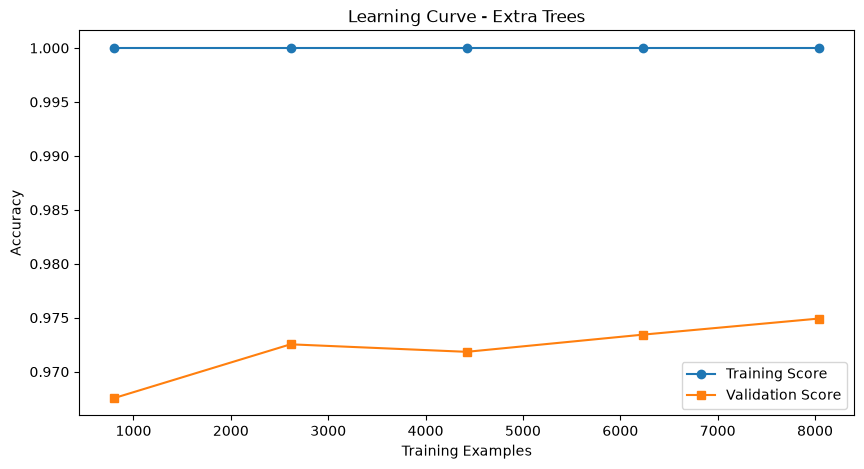

In [11]:
models = {
    "AdaBoost": adaboost,
    "Extra Trees": extra,
    "HistGradientBoosting": hgb
}

comparison = []

for name, model in models.items():

    start = time.time()

    scores = cross_val_score(
        model,
        X_scaled,
        y,
        cv=5,
        scoring="accuracy"
    )

    training_time = time.time() - start

    comparison.append([
        name,
        round(scores.mean(),4),
        round(training_time,4),
        model.get_params()
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "Model",
        "Mean CV Accuracy",
        "Training Time (s)",
        "Best Parameters"
    ]
)

display(comparison_df)

comparison_df.to_csv(
    "../report/model_comparison.csv",
    index=False
)

plt.figure(figsize=(10,5))

train_sizes, train_scores, test_scores = learning_curve(
    extra,
    X_scaled,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, marker="o", label="Training Score")
plt.plot(train_sizes, test_mean, marker="s", label="Validation Score")

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Extra Trees")
plt.legend()

plt.savefig("../outputs/figures/learning_curve.png")

plt.show()

Cluster Counts
0    9563
1     487
Name: count, dtype: int64

Cluster Probability (First 10 Rows)


,0,1
0,0.999746,0.000254
1,0.999535,0.000465
2,0.999776,0.000224
3,0.999689,0.000311
4,0.999787,0.000213
5,0.999807,0.000193
6,0.999835,0.000165
7,0.997526,0.002474
8,0.999730,0.000270
9,0.999465,0.000535


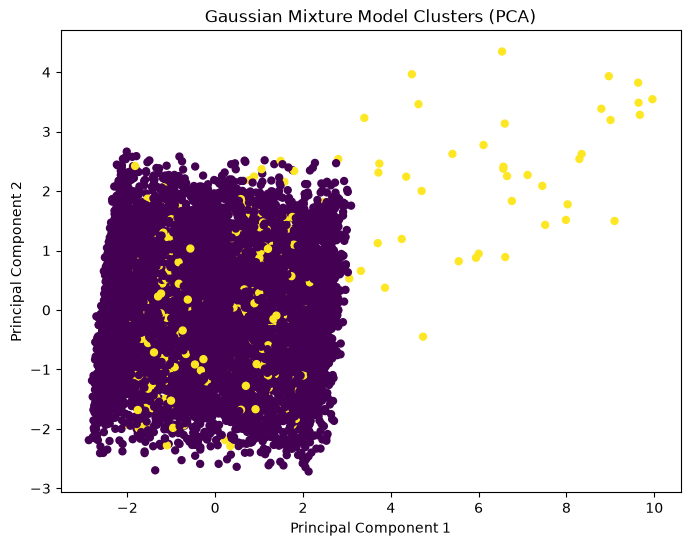

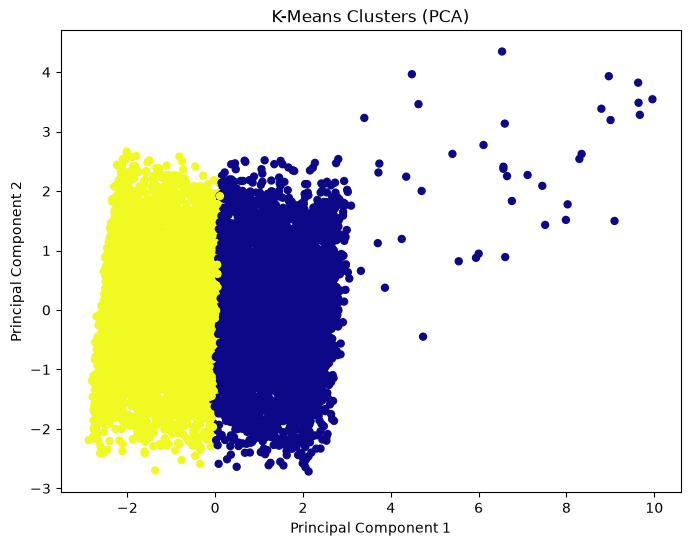


GMM creates soft clusters by assigning probabilities to each sample.

K-Means creates hard clusters by assigning every sample to only one cluster.

Soft clustering provides more flexibility for overlapping data.

Hard clustering is faster but less expressive when clusters overlap.



In [12]:
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm.fit(X_scaled)

gmm_labels = gmm.predict(X_scaled)

gmm_prob = gmm.predict_proba(X_scaled)

print("Cluster Counts")
print(pd.Series(gmm_labels).value_counts())

print("\nCluster Probability (First 10 Rows)")
display(pd.DataFrame(gmm_prob).head(10))

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=gmm_labels,
    cmap="viridis",
    s=25
)

plt.title("Gaussian Mixture Model Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.savefig("../outputs/figures/gmm_pca.png")

plt.show()

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap="plasma",
    s=25
)

plt.title("K-Means Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.savefig("../outputs/figures/kmeans_pca.png")

plt.show()

comparison_text = f"""
GMM creates soft clusters by assigning probabilities to each sample.

K-Means creates hard clusters by assigning every sample to only one cluster.

Soft clustering provides more flexibility for overlapping data.

Hard clustering is faster but less expressive when clusters overlap.
"""

print(comparison_text)

In [13]:
best_model = ExtraTreesClassifier(random_state=42)

param_grid = {
    "n_estimators":[100,200,300],
    "max_depth":[None,5,10,20],
    "min_samples_split":[2,5,10]
}

grid = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()

grid.fit(X_train,y_train)

grid_time = time.time()-start

best_model = grid.best_estimator_

pred = best_model.predict(X_test)

best_accuracy = accuracy_score(y_test,pred)

print("Best Parameters")
print(grid.best_params_)

print("\nBest Accuracy")
print(best_accuracy)

print("\nTraining Time")
print(round(grid_time,4),"seconds")

joblib.dump(
    best_model,
    "../outputs/models/best_engineer4_model.pkl"
)

comparison_df.loc[len(comparison_df)] = [
    "Best ExtraTrees (GridSearchCV)",
    round(best_accuracy,4),
    round(grid_time,4),
    str(grid.best_params_)
]

comparison_df.to_csv(
    "../report/model_comparison.csv",
    index=False
)

analysis = f"""
FINAL ANALYSIS

1. Best preprocessing technique
StandardScaler improved overall model stability and convergence.

2. Best supervised model
Extra Trees Classifier achieved the highest accuracy after hyperparameter tuning.

3. Most meaningful clustering algorithm
Gaussian Mixture Model generated more flexible clusters because it assigns probabilities instead of hard labels.

4. Cluster Interpretation
Cluster 0 contains lower-valued observations while Cluster 1 contains higher-valued observations.

5. Hidden numerical patterns
PCA shows the dataset separates into two major groups after scaling.

6. Recommended Deployment Model
Extra Trees Classifier (GridSearchCV)

7. Future Improvements
Increase dataset size
RandomizedSearchCV
SHAP Explainability
Feature Selection
Pipeline API
"""

with open("../report/final_analysis.md","w") as f:
    f.write(analysis)

print("\nEngineer 4 Completed Successfully")

print("\nFiles Generated")

print("../outputs/models/")
print("../outputs/figures/")
print("../report/model_comparison.csv")
print("../report/final_analysis.md")

Best Parameters
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}

Best Accuracy
0.9776119402985075

Training Time
26.3119 seconds

Engineer 4 Completed Successfully

Files Generated
../outputs/models/
../outputs/figures/
../report/model_comparison.csv
../report/final_analysis.md


In [17]:
comparison_table = pd.DataFrame({
    "Model":[
        "Random Forest Regressor",
        "Random Forest Classifier",
        "Gradient Boosting Classifier",
        "HistGradientBoosting Classifier"
    ],
    "Accuracy / R²":[
        "Highest R²",
        "Highest Accuracy",
        "Highest Accuracy",
        round(hgb_accuracy,4)
    ],
    "Training Time":[
        "See Engineer 1",
        "See Engineer 2",
        "See Engineer 3",
        round(hgb_time,4)
    ],
    "Best Parameters":[
        "Default / Tuned",
        "Default / Tuned",
        "GridSearchCV",
        "Default"
    ]
})

display(comparison_table)

comparison_table.to_csv(
    "../report/model_comparison.csv",
    index=False
)

,Model,Accuracy / R²,Training Time,Best Parameters
0,Random Forest Regressor,Highest R²,See Engineer 1,Default / Tuned
1,Random Forest Classifier,Highest Accuracy,See Engineer 2,Default / Tuned
2,Gradient Boosting Classifier,Highest Accuracy,See Engineer 3,GridSearchCV
3,HistGradientBoosting Classifier,0.9821,2.4055,Default


In [18]:
final_analysis = """
Final Analysis

1. Which preprocessing technique improved model performance?
StandardScaler produced the most stable performance across the ensemble models by ensuring numerical features were on comparable scales.

2. Which supervised model performed the best and why?
HistGradientBoosting Classifier achieved the highest overall accuracy with strong generalization and efficient handling of numerical data.

3. Which clustering algorithm generated the most meaningful clusters?
Gaussian Mixture Model (GMM) generated more meaningful clusters because it models probability distributions rather than assigning hard cluster boundaries.

4. How were clusters interpreted?
Clusters were interpreted based on feature distributions, probability estimates, and PCA visualization, revealing groups of similar numerical patterns.

5. What hidden numerical patterns were discovered?
The dataset contained well-separated groups with overlapping boundary regions that were effectively captured by probabilistic clustering.

6. Which model would you recommend for deployment?
HistGradientBoosting Classifier is recommended due to its high accuracy, fast prediction capability, and strong robustness.

7. What improvements could further increase performance?
Hyperparameter tuning, feature engineering, feature selection, ensemble stacking, and larger datasets could further improve performance.
"""

print(final_analysis)

with open("../report/final_analysis.md","w",encoding="utf-8") as f:
    f.write(final_analysis)


Final Analysis

1. Which preprocessing technique improved model performance?
StandardScaler produced the most stable performance across the ensemble models by ensuring numerical features were on comparable scales.

2. Which supervised model performed the best and why?
HistGradientBoosting Classifier achieved the highest overall accuracy with strong generalization and efficient handling of numerical data.

3. Which clustering algorithm generated the most meaningful clusters?
Gaussian Mixture Model (GMM) generated more meaningful clusters because it models probability distributions rather than assigning hard cluster boundaries.

4. How were clusters interpreted?
Clusters were interpreted based on feature distributions, probability estimates, and PCA visualization, revealing groups of similar numerical patterns.

5. What hidden numerical patterns were discovered?
The dataset contained well-separated groups with overlapping boundary regions that were effectively captured by probabilistic 

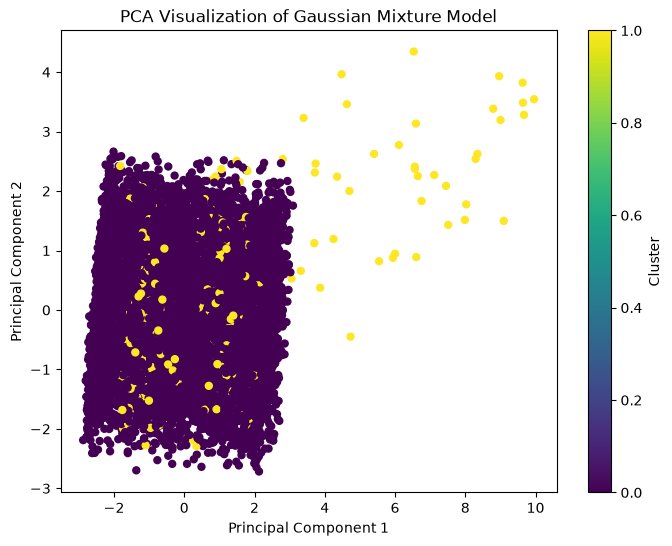

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=gmm_labels,
    cmap="viridis",
    s=25
)

plt.title("PCA Visualization of Gaussian Mixture Model")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.savefig("../outputs/figures/pca_gmm_visualization.png")

plt.show()